In [487]:
import pandas as pd
import pandas as pd
import numpy as np 

import seaborn as sns 
import matplotlib.pylab as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.model_selection import cross_val_score


from scipy.stats import norm
from scipy import stats

all_wines_original = pd.read_csv(r"D:\DataScienceKurs\BlueBerry-Winery\datasets\eda.csv")
red_wine_original = pd.read_csv(r"D:\DataScienceKurs\BlueBerry-Winery\datasets\red_wine_ml.csv")
white_wine_original = pd.read_csv(r"D:\DataScienceKurs\BlueBerry-Winery\datasets\white_wine_ml.csv")
all_wines_original

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,quality_label,wine_type,alcohol_g_per_L,acidity_to_alcohol_ratio,SO2_ratio,alc_acid_ratio
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,low,red,74.166,0.099776,32.352941,127.027027
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,low,red,77.322,0.100877,37.313433,125.641026
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,low,red,77.322,0.100877,27.777778,125.641026
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,medium,red,77.322,0.144849,28.333333,87.500000
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,low,red,74.166,0.099776,32.352941,127.027027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,medium,white,88.368,0.070161,26.086957,180.645161
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,low,white,75.744,0.087136,33.928571,145.454545
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,medium,white,74.166,0.087641,27.027027,144.615385
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,medium,white,100.992,0.054460,18.181818,232.727273


In [243]:
all_wines_original = all_wines_original.drop_duplicates()
all_wines_original.drop("quality", axis =1, inplace=True)
all_wines_original

D:\Users\Olunia\AppData\Local\Temp\ipykernel_14024\3441289596.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_wines_original.drop("quality", axis =1, inplace=True)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality_label,wine_type,alcohol_g_per_L,acidity_to_alcohol_ratio,SO2_ratio,alc_acid_ratio
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,low,red,74.166,0.099776,32.352941,127.027027
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,low,red,77.322,0.100877,37.313433,125.641026
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,low,red,77.322,0.100877,27.777778,125.641026
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,medium,red,77.322,0.144849,28.333333,87.500000
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,low,red,74.166,0.099776,32.500000,127.027027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,medium,white,88.368,0.070161,26.086957,180.645161
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,low,white,75.744,0.087136,33.928571,145.454545
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,medium,white,74.166,0.087641,27.027027,144.615385
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,medium,white,100.992,0.054460,18.181818,232.727273


### Label Encoder - Wine type

In [244]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

le = LabelEncoder()
all_wines_original['wine_type'] = le.fit_transform(all_wines_original['wine_type'])

all_wines_original['wine_type'].head()

D:\Users\Olunia\AppData\Local\Temp\ipykernel_14024\864379471.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_wines_original['wine_type'] = le.fit_transform(all_wines_original['wine_type'])


0    0
1    0
2    0
3    0
5    0
Name: wine_type, dtype: int32

### Ordinal Encoder - Quality Label

In [245]:
print(all_wines_original['quality_label'].dtype)
print(all_wines_original['quality_label'].unique())


object
['low' 'medium' 'high']


In [246]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[["low", "medium", "high"]], dtype=int) # this is how you can define the label order
all_wines_original['quality_label'] = oe.fit_transform(all_wines_original[['quality_label']])
all_wines_original['quality_label'].head()



D:\Users\Olunia\AppData\Local\Temp\ipykernel_14024\3182098399.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_wines_original['quality_label'] = oe.fit_transform(all_wines_original[['quality_label']])


0    0
1    0
2    0
3    1
5    0
Name: quality_label, dtype: int32

### Split the data - wine type

In [247]:
from sklearn.model_selection import train_test_split

X = all_wines_original.drop('wine_type', axis =1) 
y = all_wines_original['wine_type'] # --> what you're trying to predict

print("original:", all_wines_original.shape, "\nX:", X.shape, "\ny:", y.shape)

original: (5320, 17) 
X: (5320, 16) 
y: (5320,)


### Define the split

In [248]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=420)
print(X_train, X_test)

      fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
917             6.8              0.41         0.31            8.80      0.084   
1725            7.4              0.39         0.23            7.00      0.033   
2377            6.9              0.22         0.37           15.00      0.053   
5635            7.3              0.33         0.22            1.40      0.041   
1550            7.1              0.68         0.00            2.30      0.087   
...             ...               ...          ...             ...        ...   
5992            6.4              0.18         0.28           17.05      0.047   
5706            6.8              0.30         0.26           20.30      0.037   
5454            5.9              0.18         0.29            4.60      0.032   
6351            5.1              0.25         0.36            1.30      0.035   
3546            5.7              0.45         0.42            1.10      0.051   

      free_sulfur_dioxide  

### Feature Scaling

In [249]:
scaler = StandardScaler()
X_train_scaled1 = scaler.fit_transform(X_train)
X_test_scaled1 = scaler.transform(X_test)

### Building a model

#### Logistic Regression

In [250]:
from sklearn.linear_model import LogisticRegression

LR_model = LogisticRegression(max_iter=1000) 

In [251]:
LR_model.fit(X_train_scaled1, y_train)

LogisticRegression(max_iter=1000)

In [252]:
preds = LR_model.predict(X_test_scaled1)
preds

array([1, 1, 0, ..., 1, 0, 1])

In [253]:
y_test

4882    1
1981    1
636     0
5052    1
4555    1
       ..
3954    1
1443    0
1081    0
401     0
2284    1
Name: wine_type, Length: 1064, dtype: int32

In [254]:
from sklearn.metrics import accuracy_score 

acc = accuracy_score(y_test, preds)
acc

0.9924812030075187

### Random Forest

In [255]:
from sklearn.ensemble import RandomForestClassifier

In [256]:
RF_clf = RandomForestClassifier(random_state=420)

In [257]:
RF_clf.fit(X_train_scaled1, y_train)

RandomForestClassifier(random_state=420)

In [258]:
preds = RF_clf.predict(X_test_scaled1)
preds

array([1, 1, 0, ..., 0, 0, 1])

In [259]:
acc = accuracy_score(y_test, preds)
acc

0.9962406015037594

### Split the data Quality Label

In [260]:
from sklearn.model_selection import train_test_split

X = all_wines_original.drop('quality_label', axis =1) 
y = all_wines_original['quality_label'] # --> what you're trying to predict

print("original:", all_wines_original.shape, "\nX:", X.shape, "\ny:", y.shape)

original: (5320, 17) 
X: (5320, 16) 
y: (5320,)


#### Define the split

In [261]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=420)
print(X_train, X_test)

      fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
917             6.8              0.41         0.31            8.80      0.084   
1725            7.4              0.39         0.23            7.00      0.033   
2377            6.9              0.22         0.37           15.00      0.053   
5635            7.3              0.33         0.22            1.40      0.041   
1550            7.1              0.68         0.00            2.30      0.087   
...             ...               ...          ...             ...        ...   
5992            6.4              0.18         0.28           17.05      0.047   
5706            6.8              0.30         0.26           20.30      0.037   
5454            5.9              0.18         0.29            4.60      0.032   
6351            5.1              0.25         0.36            1.30      0.035   
3546            5.7              0.45         0.42            1.10      0.051   

      free_sulfur_dioxide  

In [262]:
scaler = StandardScaler()
X_train_scaled2 = scaler.fit_transform(X_train)
X_test_scaled2 = scaler.transform(X_test)

### Logistic Regression - QL

In [263]:
from sklearn.linear_model import LogisticRegression

LR_model = LogisticRegression(max_iter=1000) 
LR_model.fit(X_train_scaled2, y_train)
lr_preds = LR_model.predict(X_test_scaled2)
lr_preds

array([0, 0, 0, ..., 1, 1, 0])

In [264]:
y_test

4882    1
1981    1
636     0
5052    1
4555    1
       ..
3954    1
1443    0
1081    1
401     1
2284    0
Name: quality_label, Length: 1064, dtype: int32

In [265]:
from sklearn.metrics import accuracy_score 

acc = accuracy_score(y_test, lr_preds)
acc

0.7406015037593985

In [266]:
# # Logistic Regression - faster in one go
# from sklearn.linear_model import LogisticRegression
# # define model
# LR_model = LogisticRegression(max_iter=1000)
# # fit model
# LR_model.fit(X_train, y_train)
# # make predictions
# LR_preds = LR_model.predict(X_test)

### Random Forest - QL

In [267]:
from sklearn.ensemble import RandomForestClassifier
RF_clf = RandomForestClassifier(random_state=420)
RF_clf.fit(X_train_scaled2, y_train)

RandomForestClassifier(random_state=420)

In [268]:
rf_preds = RF_clf.predict(X_test_scaled2)
rf_preds

array([1, 0, 0, ..., 1, 1, 0])

In [269]:
# Predicting probabilities
probs = RF_clf.predict_proba(X_test_scaled2)  # Zwraca prawdopodobieństwa
print(probs)


[[0.31 0.68 0.01]
 [0.75 0.25 0.  ]
 [0.97 0.03 0.  ]
 ...
 [0.04 0.94 0.02]
 [0.3  0.69 0.01]
 [0.64 0.36 0.  ]]


In [270]:
acc = accuracy_score(y_test, rf_preds)
acc


0.7593984962406015

In [271]:
auc = metrics.roc_auc_score(y_test, probs, multi_class='ovr')
print(auc)

0.8496500456661632


In [272]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'n_estimators': [100, 200],
#     'max_depth': [2, 3],
#     'learning_rate': [0.05, 0.1],
#     'reg_alpha': [0.1, 0.2, 0.3],
#     'reg_lambda': [3, 5, 6]
# }

# grid_search = GridSearchCV(estimator=XGBClassifier(objective='multi:softprob', num_class=len(set(y_train))),
#                            param_grid=param_grid, cv=5, scoring='roc_auc_ovr')

# grid_search.fit(X_train, y_train)
# print(f'Best Parameters: {grid_search.best_params_}')

### XGBClassifier

In [273]:

# Initialize the model
models = [XGBClassifier(
    max_depth=3,
    learning_rate=0.05,
    n_estimators=200,
    reg_alpha=0.1,
    reg_lambda=3,
    objective='multi:softprob',
    num_class=len(set(y_train))
)]


for model in models:
    model.fit(X_train_scaled2, y_train)

    print(f'{model} : ')
    print('Training Accuracy : ', metrics.roc_auc_score(y_train, model.predict_proba(X_train_scaled2), multi_class='ovr'))
    print('Validation Accuracy : ', metrics.roc_auc_score(y_test, model.predict_proba(X_test_scaled2), multi_class='ovr'))
    print()

    # Perform 5-fold cross-validation
scores = cross_val_score(model, X_train_scaled2, y_train, cv=5, scoring='roc_auc_ovr')
print(f'Mean CV AUC: {scores.mean()}')

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=3,
              num_parallel_tree=None, ...) : 
Training Accuracy :  0.882071854432397
Validation Accuracy :  0.837785087844988

Mean CV AUC: 0.8069822996299555


In [274]:
from sklearn.metrics import confusion_matrix
preds = model.predict(X_test_scaled2)
train_preds = model.predict(X_train_scaled2)

print("Confusion matrix:")
print(confusion_matrix(y_test, preds))

Confusion matrix:
[[259 147   0]
 [ 91 542   0]
 [  0  25   0]]


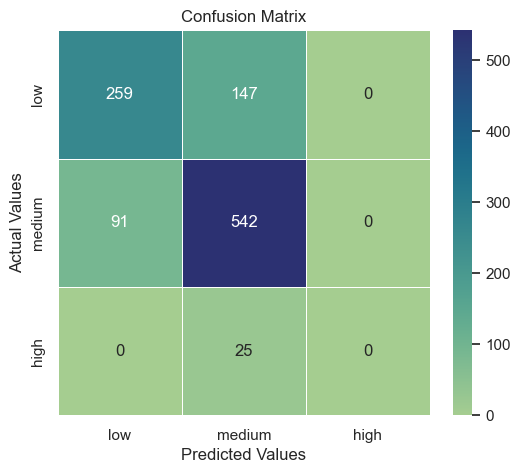

In [275]:
# Compute confusion matrix
cm = confusion_matrix(y_test, preds)

# Convert to DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['low', 'medium', 'high'], 
                     columns=['low', 'medium', 'high'])

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="crest", linewidths=0.5, cbar=True)

# Labels and title
plt.title("Confusion Matrix")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.show()

In [276]:
print("Validation accuracy score:", accuracy_score(y_test, preds))
print("Training accuracy score:", accuracy_score(y_train, train_preds))

Validation accuracy score: 0.7528195488721805
Training accuracy score: 0.7645676691729323


In [277]:
 # Perform 5-fold cross-validation
scores = cross_val_score(model, X_train_scaled2, y_train, cv=5, scoring='accuracy')
print(f'Mean CV AUC: {scores.mean()}')

Mean CV AUC: 0.7293203797796572


In [278]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds, target_names=["low","medium","high"]))

              precision    recall  f1-score   support

         low       0.74      0.64      0.69       406
      medium       0.76      0.86      0.80       633
        high       0.00      0.00      0.00        25

    accuracy                           0.75      1064
   macro avg       0.50      0.50      0.50      1064
weighted avg       0.73      0.75      0.74      1064



d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Evaluation Matrix

#### Confusion Matrix - Logistic Regression

In [279]:
from sklearn.metrics import confusion_matrix
print("Confusion matrix:")
print(confusion_matrix(y_test, lr_preds))

Confusion matrix:
[[250 156   0]
 [ 95 538   0]
 [  0  25   0]]


In [280]:
compare = pd.concat([pd.Series(lr_preds), y_test.reset_index(drop=True)], axis="columns")

def self_cm(row):
    pred, actual = row.items()
    if pred[1] == 1:
        return "TP" if pred[1] == actual[1] else "FP"
    else:
        return "TN" if pred[1] == actual[1] else "FN"

CM_col = compare.apply(self_cm, axis=1)

CM_col.value_counts()

TP    538
TN    250
FP    181
FN     95
Name: count, dtype: int64

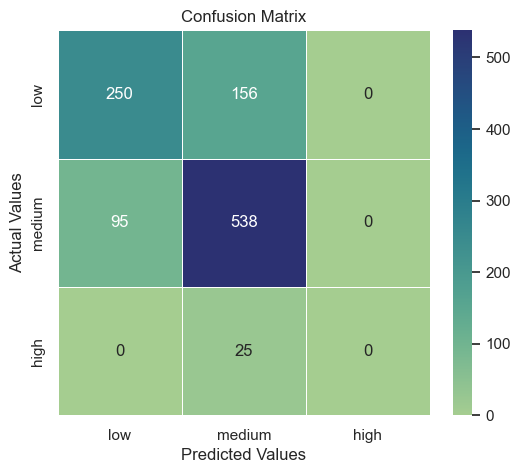

In [281]:
# Compute confusion matrix
cm = confusion_matrix(y_test, lr_preds)

# Convert to DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['low', 'medium', 'high'], 
                     columns=['low', 'medium', 'high'])

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="crest", linewidths=0.5, cbar=True)

# Labels and title
plt.title("Confusion Matrix")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.show()

In [282]:
print("Accuracy score:", accuracy_score(y_test, lr_preds))

Accuracy score: 0.7406015037593985


In [283]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_preds, target_names=["low","medium","high"]))

              precision    recall  f1-score   support

         low       0.72      0.62      0.67       406
      medium       0.75      0.85      0.80       633
        high       0.00      0.00      0.00        25

    accuracy                           0.74      1064
   macro avg       0.49      0.49      0.49      1064
weighted avg       0.72      0.74      0.73      1064



d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [284]:
from sklearn.metrics import cohen_kappa_score
print(cohen_kappa_score(y_test, lr_preds))

0.4530367909048071


### Confusion Matrix - Random Forest

In [285]:
print("Confusion matrix:")
print(confusion_matrix(y_test, rf_preds))

Confusion matrix:
[[262 144   0]
 [ 87 546   0]
 [  0  25   0]]


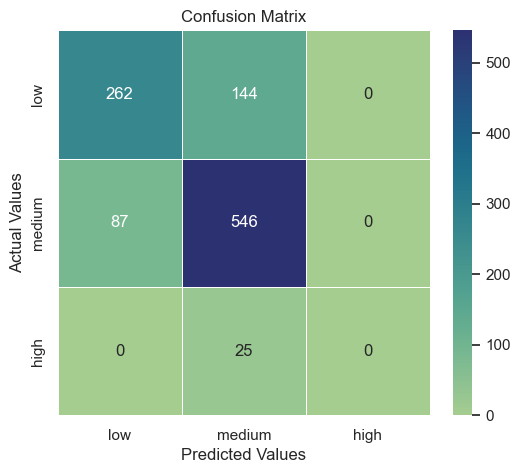

In [286]:
# Compute confusion matrix
cm = confusion_matrix(y_test, rf_preds)

# Convert to DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['low', 'medium', 'high'], 
                     columns=['low', 'medium', 'high'])

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="crest", linewidths=0.5, cbar=True)

# Labels and title
plt.title("Confusion Matrix")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.show()

In [287]:
print("Accuracy score:", accuracy_score(y_test, rf_preds))

Accuracy score: 0.7593984962406015


In [288]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_preds, target_names=["low","medium","high"], zero_division = 0)) # zero_division = 0 means that when dividing by 0 it will equal 0. It is better option (than = 1) for accurate reporting of model performance.

              precision    recall  f1-score   support

         low       0.72      0.62      0.67       406
      medium       0.75      0.85      0.80       633
        high       0.00      0.00      0.00        25

    accuracy                           0.74      1064
   macro avg       0.49      0.49      0.49      1064
weighted avg       0.72      0.74      0.73      1064



In [289]:
from sklearn.metrics import cohen_kappa_score
print(cohen_kappa_score(y_test, lr_preds))

0.4530367909048071


### Imbalanced Data - SMOTE

In [290]:
from imblearn.over_sampling import SMOTE

In [291]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import numpy as np

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Apply SMOTE to the training data
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


# Print before and after class distribution
print("Original class distribution:", np.bincount(y_train))
print("Resampled class distribution:", np.bincount(y_train_resampled))

Original class distribution: [1378 2232  114]
Resampled class distribution: [2232 2232 2232]


In [292]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler(feature_range=(0,1))

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train_resampled)

# Transform the test data (do NOT fit again)
X_test_scaled = scaler.transform(X_test)

In [293]:
# Step 3: Train Machine Learning Model (Random Forest)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train_resampled)

# Step 4: Predict & Evaluate Model
y_pred = clf.predict(X_test_scaled)
pred_tr = clf.predict(X_train_scaled)


# Print Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[431 177   2]
 [210 687  50]
 [  1  29   9]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.71      0.69       610
           1       0.77      0.73      0.75       947
           2       0.15      0.23      0.18        39

    accuracy                           0.71      1596
   macro avg       0.53      0.55      0.54      1596
weighted avg       0.72      0.71      0.71      1596



In [294]:
print("Accuracy score:", accuracy_score(y_test, y_pred))
print("Training Acc", accuracy_score(y_train_resampled, pred_tr))

# Accuracy = (Correct Predictions) / (Total Predictions)

# If the total number of predictions increased significantly, accuracy can decrease, even if the model is making more correct predictions overall.

Accuracy score: 0.706140350877193
Training Acc 1.0


In [295]:

from sklearn.metrics import cohen_kappa_score
print(cohen_kappa_score(y_test, y_pred))

0.42753524541392807


In [296]:
 # Perform 5-fold cross-validation
scores = cross_val_score(model, X_train_scaled, y_train_resampled, cv=5, scoring='accuracy')
print(f'Mean CV AUC: {scores.mean()}')

Mean CV AUC: 0.7494064405381606


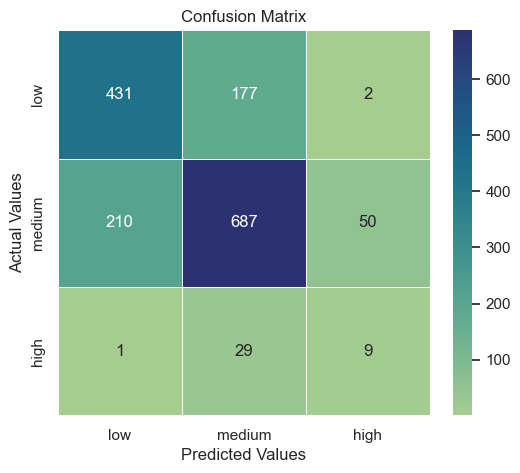

In [297]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert to DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['low', 'medium', 'high'], 
                     columns=['low', 'medium', 'high'])

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="crest", linewidths=0.5, cbar=True)

# Labels and title
plt.title("Confusion Matrix")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.show()

### WHITE WINE

In [488]:
white_wine_original

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,quality_label,wine_type,alcohol_g_per_L,acidity_to_alcohol_ratio,SO2_ratio,alc_acid_ratio,density_to_sugar_ratio,sugar_to_sulfur
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6,medium,white,69.432,0.100818,26.470588,125.714286,0.048357,0.121765
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6,medium,white,74.955,0.084050,10.606061,150.793651,0.621250,0.012121
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6,medium,white,79.689,0.101645,30.927835,124.691358,0.144217,0.071134
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,medium,white,78.111,0.092177,25.268817,137.500000,0.117129,0.045699
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,medium,white,78.111,0.092177,25.268817,137.500000,0.117129,0.045699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,medium,white,88.368,0.070161,26.086957,180.645161,0.619463,0.017391
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,low,white,75.744,0.087136,33.928571,145.454545,0.124363,0.047619
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,medium,white,74.166,0.087641,27.027027,144.615385,0.827117,0.010811
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,medium,white,100.992,0.054460,18.181818,232.727273,0.898809,0.010000


In [489]:
white_wine_original["quality_label"] = white_wine_original["quality"].apply(
    lambda value: 'low' if value <= 5 else 'medium' if value <= 7 else 'high'
)

# Convert the 'quality_label' column to a categorical type with an ordered range
white_wine_original["quality_label"] = pd.Categorical(
    white_wine_original["quality_label"],
    categories=["low", "medium", "high"],
    ordered=True
)


In [490]:
white_wine_original = white_wine_original.drop_duplicates()
white_wine_original.drop("quality", axis =1, inplace = True)
white_wine_original

D:\Users\Olunia\AppData\Local\Temp\ipykernel_14024\3181216935.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  white_wine_original.drop("quality", axis =1, inplace = True)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality_label,wine_type,alcohol_g_per_L,acidity_to_alcohol_ratio,SO2_ratio,alc_acid_ratio,density_to_sugar_ratio,sugar_to_sulfur
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,medium,white,69.432,0.100818,26.470588,125.714286,0.048357,0.121765
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,medium,white,74.955,0.084050,10.606061,150.793651,0.621250,0.012121
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,medium,white,79.689,0.101645,30.927835,124.691358,0.144217,0.071134
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,medium,white,78.111,0.092177,25.268817,137.500000,0.117129,0.045699
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.99490,3.18,0.47,9.6,medium,white,75.744,0.081855,22.058824,154.838710,0.142129,0.051471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,medium,white,88.368,0.070161,26.086957,180.645161,0.619463,0.017391
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,low,white,75.744,0.087136,33.928571,145.454545,0.124363,0.047619
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,medium,white,74.166,0.087641,27.027027,144.615385,0.827117,0.010811
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,medium,white,100.992,0.054460,18.181818,232.727273,0.898809,0.010000


In [491]:
le = LabelEncoder()
white_wine_original['wine_type'] = le.fit_transform(white_wine_original['wine_type'])

white_wine_original['wine_type'].head()


D:\Users\Olunia\AppData\Local\Temp\ipykernel_14024\3834347607.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  white_wine_original['wine_type'] = le.fit_transform(white_wine_original['wine_type'])


0    0
1    0
2    0
3    0
6    0
Name: wine_type, dtype: int32

In [492]:
oe = OrdinalEncoder(categories=[["low", "medium", "high"]], dtype=int) # this is how you can define the label order
white_wine_original['quality_label'] = oe.fit_transform(white_wine_original[['quality_label']])
white_wine_original['quality_label'].head()

D:\Users\Olunia\AppData\Local\Temp\ipykernel_14024\2797787695.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  white_wine_original['quality_label'] = oe.fit_transform(white_wine_original[['quality_label']])


0    1
1    1
2    1
3    1
6    1
Name: quality_label, dtype: int32

In [520]:
from sklearn.model_selection import train_test_split

X = white_wine_original.drop('quality_label', axis =1) 
y = white_wine_original['quality_label'] # --> what you're trying to predict

print("original:", white_wine_original.shape, "\nX:", X.shape, "\ny:", y.shape)

original: (3961, 19) 
X: (3961, 18) 
y: (3961,)


In [521]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=420)
print(X_train, X_test)

      fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
541             7.2             0.460         0.65           10.40      0.050   
2361            8.2             0.250         0.46            3.75      0.050   
1386            5.6             0.490         0.13            4.50      0.039   
929             6.1             0.360         0.58           15.00      0.044   
3834            6.5             0.410         0.22            4.80      0.052   
...             ...               ...          ...             ...        ...   
950             7.6             0.345         0.26            1.90      0.043   
686             6.8             0.220         0.35            5.50      0.043   
470             8.6             0.370         0.70           12.15      0.039   
1299            7.8             0.230         0.28            4.75      0.042   
3669            5.9             0.370         0.32            1.60      0.029   

      free_sulfur_dioxide  

In [ ]:
# from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler

# # Standardize the dataset (important for PCA)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # Apply PCA
# pca = PCA(n_components=5)  # Keep the top 5 principal components
# X_train_pca = pca.fit_transform(X_train_scaled)
# X_test_pca = pca.transform(X_test_scaled)

# # Explained variance ratio (how much information each component holds)
# print("Explained variance:", pca.explained_variance_ratio_)
# print("Total variance explained:", sum(pca.explained_variance_ratio_))

Explained variance: [0.33016964 0.14087071 0.112661   0.09368837 0.06651065]
Total variance explained: 0.7439003665000811


### SMOTE default

In [ ]:
# # Split into training and test sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=420)

# # Apply SMOTE to the training data
# smote = SMOTE(sampling_strategy='auto', random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# # Print before and after class distribution
# print("Original class distribution:", np.bincount(y_train))
# print("Resampled class distribution:", np.bincount(y_train_resampled))

Original class distribution: [ 960 1721   91]
Resampled class distribution: [1721 1721 1721]


### SMOTE for high quality wine

In [ ]:
# from imblearn.over_sampling import SMOTE

# # Podział na zbiór treningowy i testowy
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=420)

# # Sprawdzenie liczności klas przed SMOTE
# print("Liczność klas przed SMOTE:", np.bincount(y_train))

# # Zastosowanie SMOTE tylko dla klasy 'high'
# smote = SMOTE(sampling_strategy={2: 500}, random_state=42)  # Ustaw docelową liczność klasy 'high'
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# # Sprawdzenie liczności klas po SMOTE
# print("Liczność klas po SMOTE:", np.bincount(y_train_resampled))

Liczność klas przed SMOTE: [ 960 1721   91]
Liczność klas po SMOTE: [ 960 1721  500]


In [ ]:
# from sklearn.preprocessing import MinMaxScaler

# # Initialize the scaler
# scaler = MinMaxScaler(feature_range=(0,1))

# # Fit and transform the training data
# X_train_scaled = scaler.fit_transform(X_train)

# # Transform the test data (do NOT fit again)
# X_test_scaled = scaler.transform(X_test)

In [385]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Assuming y_resampled contains your target variable after applying SMOTE
# value_counts = pd.Series(y_train_resampled).value_counts()

# # Custom background color
# fig = plt.figure(figsize=(8, 6))
# fig.patch.set_facecolor('#f3ede3')  # Set figure background color

# # Plotting with the Cividis color palette
# sns.set(style="whitegrid")  # To add a grid to the background if preferred
# ax = sns.barplot(x=value_counts.index, y=value_counts.values, palette='cividis')

# # Set the background color of the plot area
# ax.set_facecolor('#f3ede3')  # Set axes background color

# # Add title and labels
# plt.title("Class Distribution After SMOTE")
# plt.xlabel("Quality Class")
# plt.ylabel("Frequency")

# # Show plot
# plt.show()

# # Display value counts
# # print(value_counts)



## Logistic Regression White Wine

In [503]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score  

LR_model = LogisticRegression(max_iter=1000) 

LR_model.fit(X_train, y_train)

d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [537]:
preds = LR_model.predict(X_test)
acc = accuracy_score(y_test, preds)
acc

0.7384356602186711

### Random Forest

In [522]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

RF_clf = RandomForestClassifier(random_state=42)
RF_clf.fit(X_train, y_train)

preds = RF_clf.predict(X_test)
acc = accuracy_score(y_test, preds)
acc

import numpy as np


preds_prob = RF_clf.predict_proba(X_test)
print(preds_prob)

[[0.08 0.84 0.08]
 [0.21 0.77 0.02]
 [0.3  0.7  0.  ]
 ...
 [0.08 0.88 0.04]
 [0.64 0.35 0.01]
 [0.03 0.83 0.14]]


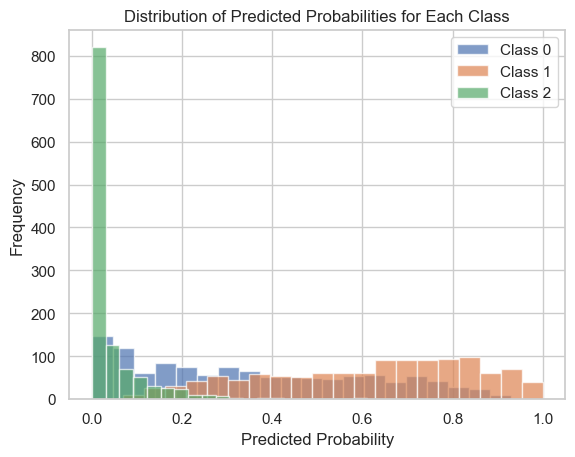

In [539]:
# Plot the distribution of probabilities for each class
for i in range(preds_prob.shape[1]):  # For each class
    plt.hist(preds_prob[:, i], bins=20, alpha=0.7, label=f'Class {i}')
    
plt.title('Distribution of Predicted Probabilities for Each Class')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [540]:
# Get the predicted class labels
pred_labels = RF_clf.predict(X_test)

# Calculate the average confidence level for the predicted class (for each sample)
average_confidence = np.mean([preds_prob[i][pred_labels[i]] for i in range(len(pred_labels))])

print(f"Average Confidence: {average_confidence:.4f}")

Average Confidence: 0.7207


In [542]:
# For each class, calculate the average confidence level for all predictions made to that class
for class_idx in range(preds_prob.shape[1]):
    class_confidence = np.mean(preds_prob[:, class_idx])
    print(f"Average confidence for class {class_idx}: {class_confidence:.4f}")

Average confidence for class 0: 0.3498
Average confidence for class 1: 0.6093
Average confidence for class 2: 0.0409


In [523]:
import pandas as pd

df = pd.DataFrame(preds_prob, columns=['Low (0)', 'Medium (1)', 'High (2)'])
df['Predicted Class'] = preds_prob.argmax(axis=1)
print(df)

      Low (0)  Medium (1)  High (2)  Predicted Class
0        0.08        0.84      0.08                1
1        0.21        0.77      0.02                1
2        0.30        0.70      0.00                1
3        0.50        0.50      0.00                0
4        0.33        0.67      0.00                1
...       ...         ...       ...              ...
1184     0.36        0.64      0.00                1
1185     0.20        0.71      0.09                1
1186     0.08        0.88      0.04                1
1187     0.64        0.35      0.01                0
1188     0.03        0.83      0.14                1

[1189 rows x 4 columns]


In [531]:
print(y_test.head(10))
y_test = y_test.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

2631    1
1115    2
388     1
2307    0
4461    1
2537    1
3603    1
1372    1
226     1
1484    0
Name: quality_label, dtype: int32


In [532]:
comparison = pd.DataFrame({'True Label': y_test, 'Predicted Label': df['Predicted Class']})
print(comparison.head(10))

   True Label  Predicted Label
0           1                1
1           2                1
2           1                1
3           0                0
4           1                1
5           1                0
6           1                1
7           1                0
8           1                1
9           0                0


In [ ]:
pred_labels = preds_prob.argmax(axis=1)
# Compute accuracy
acc_prob = accuracy_score(y_test, pred_labels)
print("Accuracy Probability:", acc_prob)

acc = accuracy_score(y_test, preds)
print("Accuracy:", acc) 

Accuracy Probability: 0.7628259041211102
Accuracy: 0.7628259041211102


In [536]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Train the RandomForestClassifier
RF_clf = RandomForestClassifier(random_state=42)
RF_clf.fit(X_train, y_train)

# Predict class labels
preds = RF_clf.predict(X_test)

# Compute accuracy using predicted labels
acc = accuracy_score(y_test, preds)
print("Accuracy (Class labels):", acc)

# Predict probabilities
preds_prob = RF_clf.predict_proba(X_test)

# Convert probabilities to class labels based on max probability
pred_labels = preds_prob.argmax(axis=1)

# Compute accuracy using predicted labels from probabilities
acc_prob = accuracy_score(y_test, pred_labels)
print("Accuracy (Based on Probabilities):", acc_prob)

# Print probability predictions
print("Predicted Probabilities:")
print(preds_prob)

# Optionally, print confusion matrix and classification report
print("Confusion Matrix:")
print(confusion_matrix(y_test, preds))

print("Classification Report:")
print(classification_report(y_test, preds))


Accuracy (Class labels): 0.7628259041211102
Accuracy (Based on Probabilities): 0.7628259041211102
Predicted Probabilities:
[[0.08 0.84 0.08]
 [0.21 0.77 0.02]
 [0.3  0.7  0.  ]
 ...
 [0.08 0.88 0.04]
 [0.64 0.35 0.01]
 [0.03 0.83 0.14]]
Confusion Matrix:
[[266 122   0]
 [116 639   1]
 [  0  43   2]]
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.69      0.69       388
           1       0.79      0.85      0.82       756
           2       0.67      0.04      0.08        45

    accuracy                           0.76      1189
   macro avg       0.72      0.53      0.53      1189
weighted avg       0.76      0.76      0.75      1189



In [534]:
print("Confusion matrix:")
print(confusion_matrix(y_test, preds))

Confusion matrix:
[[266 122   0]
 [116 639   1]
 [  0  43   2]]


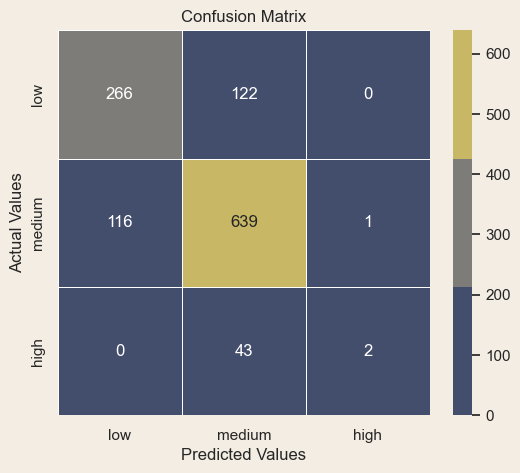

In [500]:
# Compute confusion matrix

cm = confusion_matrix(y_test, preds)

# Convert to DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['low', 'medium', 'high'], 
                     columns=['low', 'medium', 'high'])

# Load the cividis colormap from Matplotlib
cividis = plt.get_cmap("cividis")

# Choose specific gradient positions (values from 0 to 1)
colors = [cividis(0.25), cividis(0.5), cividis(0.8)]  # Adjust these values to change the colors

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
# Apply these colors to the heatmap
sns.heatmap(cm_df, annot=True, fmt="d", cmap=sns.color_palette(colors, as_cmap=True), linewidths=0.5, cbar=True)

# Labels and title
plt.title("Confusion Matrix")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.gcf().set_facecolor('#f3ede3')
plt.show()



In [501]:
print(classification_report(y_test, preds, target_names=["low","medium","high"]))

              precision    recall  f1-score   support

         low       0.70      0.69      0.69       388
      medium       0.79      0.85      0.82       756
        high       0.67      0.04      0.08        45

    accuracy                           0.76      1189
   macro avg       0.72      0.53      0.53      1189
weighted avg       0.76      0.76      0.75      1189



In [480]:
print("Accuracy score:", accuracy_score(y_test, preds))
from sklearn.metrics import cohen_kappa_score
print(f"Cohen Kappa Score: {cohen_kappa_score(y_test, preds)}")

Accuracy score: 0.7342304457527334
Cohen Kappa Score: 0.42315227070347283


In [481]:
  # Perform 5-fold cross-validation
scores = cross_val_score(model, X_train_pca, y_train, cv=5, scoring='accuracy')
print(f'Mean CV Accuracy: {scores.mean()}')

Mean CV Accuracy: 0.7023833219501088


In [221]:
import numpy as np

n_estimators = np.arange(10,501,50)
max_depth = np.arange(5,20,2)
min_samples_split = np.arange(2, 15, 2)
max_features = ["sqrt", "log2", None]

param_grid = {
  'n_estimators': n_estimators,
  'max_depth': max_depth,
  'min_samples_split': min_samples_split,
  'max_features': max_features,
}

param_grid

from sklearn.model_selection import RandomizedSearchCV

# redefine model
RF_clf = RandomForestClassifier(random_state=42)

RS_grid = RandomizedSearchCV(estimator=RF_clf, param_distributions=param_grid, n_iter=10)
RS_grid

RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                   param_distributions={'max_depth': array([ 5,  7,  9, 11, 13, 15, 17, 19]),
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14]),
                                        'n_estimators': array([ 10,  60, 110, 160, 210, 260, 310, 360, 410, 460])})

In [ ]:
RS_grid.fit(X_train_scaled, y_train)
print(
  'best score: ', RS_grid.best_score_,
  '\nparams: ', RS_grid.best_params_
)

best score:  0.7315442868003514 
params:  {'n_estimators': 410, 'min_samples_split': 2, 'max_features': None, 'max_depth': 11}


In [486]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=420)
rf.fit(X_train, y_train)

# Get Feature Importance
feature_importances = rf.feature_importances_

# Create a DataFrame to view results
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print top features
print(feature_importance_df)

                     Feature  Importance
1           volatile_acidity    0.086599
10                   alcohol    0.072094
5        free_sulfur_dioxide    0.066630
7                    density    0.065793
14                 SO2_ratio    0.065628
15            alc_acid_ratio    0.064549
12           alcohol_g_per_L    0.063832
2                citric_acid    0.063786
13  acidity_to_alcohol_ratio    0.056481
6       total_sulfur_dioxide    0.055796
4                  chlorides    0.055456
17           sugar_to_sulfur    0.053756
16    density_to_sugar_ratio    0.051021
8                         pH    0.050171
9                  sulphates    0.049954
3             residual_sugar    0.041469
0              fixed_acidity    0.036983
11                 wine_type    0.000000


In [467]:
from sklearn.model_selection import GridSearchCV
import numpy as np

max_features_range = np.arange(1,6,1)
n_estimators_range = np.arange(10,210,10)
param_grid = dict(max_features=max_features_range, n_estimators=n_estimators_range)

rf = RandomForestClassifier()

grid = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5)

In [225]:
grid.fit(X_train_scaled, y_train_resampled)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_features': array([1, 2, 3, 4, 5]),
                         'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200])})

In [226]:
print("The best parameters are %s with a score of %0.2f"
      % (grid.best_params_, grid.best_score_))

The best parameters are {'max_features': 1, 'n_estimators': 160} with a score of 0.75


In [6290]:
import pandas as pd

grid_results = pd.concat([pd.DataFrame(grid.cv_results_["params"]),pd.DataFrame(grid.cv_results_["mean_test_score"], columns=["Accuracy"])],axis=1)
grid_results

,max_features,n_estimators,Accuracy
0,1,10,0.709600
1,1,20,0.713567
2,1,30,0.715371
3,1,40,0.717541
4,1,50,0.723308
...,...,...,...
95,5,160,0.725833
96,5,170,0.722949
97,5,180,0.722950
98,5,190,0.724391


In [468]:
class_weights = {0: 1, 1: 1, 2: 4}

model = RandomForestClassifier(
    n_estimators= 160,
    # min_samples_split = 14,
    max_features= 1,
    # max_depth = 14,
    class_weight = class_weights
)

model.fit(X_train_scaled,y_train)
train_preds = model.predict(X_train_scaled)
test_preds = model.predict(X_test_scaled)

print('Training Accuracy : ', accuracy_score(y_train, train_preds))
print('Validation Accuracy : ', accuracy_score(y_test, test_preds))
print()

# Perform 5-fold cross-validation
scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'Mean CV Accuracy: {scores.mean()}')
print(f"Cohen Kappa Score: {cohen_kappa_score(y_test, test_preds)}")



Training Accuracy :  1.0
Validation Accuracy :  0.7547931382441978

Mean CV Accuracy: 0.7313131313131314
Cohen Kappa Score: 0.463250945612514


In [469]:
print("Confusion matrix:")
print(confusion_matrix(y_test, preds))

Confusion matrix:
[[205 112   0]
 [ 98 538   2]
 [  0  35   1]]


In [240]:
print(classification_report(y_test, preds, target_names=["low","medium","high"]))

              precision    recall  f1-score   support

         low       0.69      0.67      0.68       388
      medium       0.79      0.81      0.80       756
        high       0.22      0.18      0.20        45

    accuracy                           0.74      1189
   macro avg       0.57      0.55      0.56      1189
weighted avg       0.74      0.74      0.74      1189



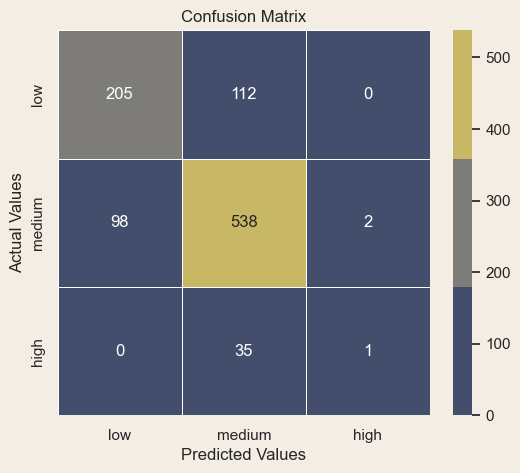

In [470]:
# Compute confusion matrix

cm = confusion_matrix(y_test, preds)

# Convert to DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['low', 'medium', 'high'], 
                     columns=['low', 'medium', 'high'])

# Load the cividis colormap from Matplotlib
cividis = plt.get_cmap("cividis")

# Choose specific gradient positions (values from 0 to 1)
colors = [cividis(0.25), cividis(0.5), cividis(0.8)]  # Adjust these values to change the colors

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
# Apply these colors to the heatmap
sns.heatmap(cm_df, annot=True, fmt="d", cmap=sns.color_palette(colors, as_cmap=True), linewidths=0.5, cbar=True)

# Labels and title
plt.title("Confusion Matrix")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.gcf().set_facecolor('#f3ede3')
plt.show()

In [6281]:
# define the tree depths to evaluate
values = [i for i in range(2, 21)]

test_scores =[]
train_scores = []

# evaluate a decision tree for each depth
for i in values:
	# configure the model
	model = RandomForestClassifier(max_depth=i)
	# fit model on the training dataset
	model.fit(X_train_scaled, y_train)
	# evaluate on the train _scadataset
	train_yhat = model.predict(X_train_scaled)
	train_acc = accuracy_score(y_train, train_yhat)
	train_scores.append(train_acc)
	# evaluate on the test dataset
	test_yhat = model.predict(X_test_scaled)
	test_acc = accuracy_score(y_test, test_yhat)
	test_scores.append(test_acc)
	# summarize progress
	print('>%d, train: %.3f, test: %.3f' % (i, train_acc, test_acc))

>2, train: 0.706, test: 0.712
>3, train: 0.722, test: 0.731
>4, train: 0.741, test: 0.739
>5, train: 0.763, test: 0.747
>6, train: 0.790, test: 0.755
>7, train: 0.819, test: 0.759
>8, train: 0.845, test: 0.749
>9, train: 0.878, test: 0.748
>10, train: 0.912, test: 0.748
>11, train: 0.935, test: 0.748
>12, train: 0.954, test: 0.752
>13, train: 0.966, test: 0.748
>14, train: 0.977, test: 0.756
>15, train: 0.982, test: 0.749
>16, train: 0.987, test: 0.753
>17, train: 0.992, test: 0.747
>18, train: 0.996, test: 0.751
>19, train: 0.997, test: 0.750
>20, train: 0.999, test: 0.743


### Will removing not relevant columns help?

In [324]:
from sklearn.preprocessing import MinMaxScaler

white_wine_original

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality_label,wine_type,alcohol_g_per_L,acidity_to_alcohol_ratio,SO2_ratio,alc_acid_ratio,density_to_sugar_ratio,sugar_to_sulfur
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,1,0,69.432,0.100818,26.470588,125.714286,0.048357,0.121765
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,1,0,74.955,0.084050,10.606061,150.793651,0.621250,0.012121
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,1,0,79.689,0.101645,30.927835,124.691358,0.144217,0.071134
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,1,0,78.111,0.092177,25.268817,137.500000,0.117129,0.045699
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.99490,3.18,0.47,9.6,1,0,75.744,0.081855,22.058824,154.838710,0.142129,0.051471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,1,0,88.368,0.070161,26.086957,180.645161,0.619463,0.017391
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,0,0,75.744,0.087136,33.928571,145.454545,0.124363,0.047619
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,1,0,74.166,0.087641,27.027027,144.615385,0.827117,0.010811
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,1,0,100.992,0.054460,18.181818,232.727273,0.898809,0.010000


In [446]:
white_wine_dropped_columns = white_wine_original.drop(['sulphates','fixed_acidity','residual_sugar','density','density_to_sugar_ratio'], axis = 1)

In [447]:
white_wine_dropped_columns

,volatile_acidity,citric_acid,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,pH,alcohol,quality_label,wine_type,alcohol_g_per_L,acidity_to_alcohol_ratio,SO2_ratio,alc_acid_ratio,sugar_to_sulfur
0,0.27,0.36,0.045,45.0,170.0,3.00,8.8,1,0,69.432,0.100818,26.470588,125.714286,0.121765
1,0.30,0.34,0.049,14.0,132.0,3.30,9.5,1,0,74.955,0.084050,10.606061,150.793651,0.012121
2,0.28,0.40,0.050,30.0,97.0,3.26,10.1,1,0,79.689,0.101645,30.927835,124.691358,0.071134
3,0.23,0.32,0.058,47.0,186.0,3.19,9.9,1,0,78.111,0.092177,25.268817,137.500000,0.045699
6,0.32,0.16,0.045,30.0,136.0,3.18,9.6,1,0,75.744,0.081855,22.058824,154.838710,0.051471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,0.21,0.29,0.039,24.0,92.0,3.27,11.2,1,0,88.368,0.070161,26.086957,180.645161,0.017391
4894,0.32,0.36,0.047,57.0,168.0,3.15,9.6,0,0,75.744,0.087136,33.928571,145.454545,0.047619
4895,0.24,0.19,0.041,30.0,111.0,2.99,9.4,1,0,74.166,0.087641,27.027027,144.615385,0.010811
4896,0.29,0.30,0.022,20.0,110.0,3.34,12.8,1,0,100.992,0.054460,18.181818,232.727273,0.010000


In [448]:
from sklearn.model_selection import train_test_split

X = white_wine_dropped_columns.drop('quality_label', axis = 1) 
y = white_wine_dropped_columns['quality_label'] 

print("original:", white_wine_dropped_columns.shape, "\nX:", X.shape, "\ny:", y.shape)

original: (3961, 14) 
X: (3961, 13) 
y: (3961,)


In [449]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=420)
print(X_train, X_test)

# Initialize the scaler
scaler = MinMaxScaler(feature_range=(0,1))

# Fit and transform the training data
X_train_scaled3 = scaler.fit_transform(X_train)

# Transform the test data (do NOT fit again)
X_test_scaled3 = scaler.transform(X_test)


      volatile_acidity  citric_acid  chlorides  free_sulfur_dioxide  \
4726             0.480         0.48      0.035                 35.0   
852              0.180         0.36      0.036                 40.0   
815              0.300         0.17      0.040                 24.0   
4515             0.280         0.26      0.039                 50.0   
2302             0.260         0.18      0.055                 50.0   
...                ...          ...        ...                  ...   
950              0.345         0.26      0.043                 15.0   
686              0.220         0.35      0.043                 21.0   
470              0.370         0.70      0.039                 21.0   
1299             0.230         0.28      0.042                 45.0   
3669             0.370         0.32      0.029                 41.0   

      total_sulfur_dioxide    pH  alcohol  wine_type  alcohol_g_per_L  \
4726                  96.0  3.49     12.2          0           96.258   
8

Logistic Regression

In [450]:
LR_model = LogisticRegression(max_iter=1000) 
LR_model.fit(X_train_scaled3, y_train)
preds = LR_model.predict(X_test_scaled3)
y_test
acc = accuracy_score(y_test, preds)
acc

0.7366296670030272

Random Forest 

In [451]:
from sklearn.ensemble import RandomForestClassifier
RF_clf = RandomForestClassifier(class_weight = 'balanced',random_state=42)
RF_clf.fit(X_train_scaled3, y_train)
preds = RF_clf.predict(X_test_scaled3)
acc = accuracy_score(y_test, preds)
acc

0.7598385469223007

In [437]:
print(f"Cohen Kappa Score: {cohen_kappa_score(y_test, preds)}")

Cohen Kappa Score: 0.47424829083549


In [438]:
  # Perform 5-fold cross-validation
scores = cross_val_score(model, X_train_scaled3, y_train, cv=5, scoring='accuracy')
print(f'Mean CV Accuracy: {scores.mean()}')

Mean CV Accuracy: 0.732996632996633


In [453]:
print(classification_report(y_test, preds, target_names=["low","medium","high"]))

              precision    recall  f1-score   support

         low       0.69      0.66      0.67       317
      medium       0.79      0.85      0.82       638
        high       0.50      0.03      0.05        36

    accuracy                           0.76       991
   macro avg       0.66      0.51      0.52       991
weighted avg       0.75      0.76      0.75       991



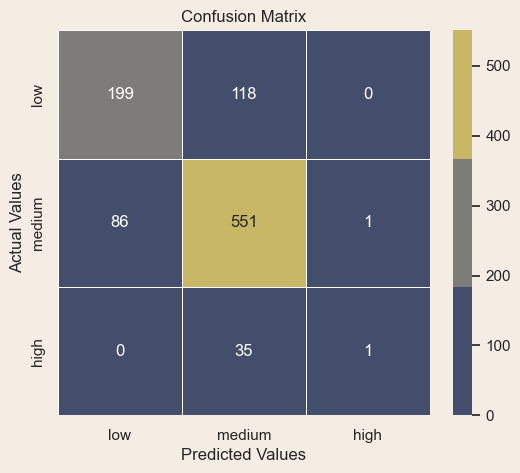

In [6195]:
# Compute confusion matrix

cm = confusion_matrix(y_test, preds)

# Convert to DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['low', 'medium', 'high'], 
                     columns=['low', 'medium', 'high'])

# Load the cividis colormap from Matplotlib
cividis = plt.get_cmap("cividis")

# Choose specific gradient positions (values from 0 to 1)
colors = [cividis(0.25), cividis(0.5), cividis(0.8)]  # Adjust these values to change the colors

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
# Apply these colors to the heatmap
sns.heatmap(cm_df, annot=True, fmt="d", cmap=sns.color_palette(colors, as_cmap=True), linewidths=0.5, cbar=True)

# Labels and title
plt.title("Confusion Matrix")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.gcf().set_facecolor('#f3ede3')
plt.show()

In [6196]:
  # Perform 5-fold cross-validation
scores = cross_val_score(model, X_train_scaled3, y_train, cv=5, scoring='accuracy')
print(f'Mean CV Accuracy: {scores.mean()}')

Mean CV Accuracy: 0.7242424242424242


#### XGBoost

In [452]:
# Initialize the model
models = [XGBClassifier(
    max_depth=3,
    learning_rate=0.05,
    n_estimators=200,
    reg_alpha=0.1,
    reg_lambda=3,
    objective='multi:softmax',
    num_class=len(set(y_train))
)]


model.fit(X_train_scaled3, y_train)
train_preds = model.predict(X_train_scaled3)
test_preds = model.predict(X_test_scaled3)

print('Training Accuracy : ', accuracy_score(y_train, train_preds))
print('Validation Accuracy : ', accuracy_score(y_test, test_preds))

# Perform 5-fold cross-validation
scores = cross_val_score(model, X_train_scaled3, y_train, cv=5, scoring='accuracy')
print(f'Mean CV Accuracy : {scores.mean()}')
print()

print('Training Accuracy Probability : ', metrics.roc_auc_score(y_train, model.predict_proba(X_train_scaled3), multi_class='ovr'))
print('Validation Accuracy Probability : ', metrics.roc_auc_score(y_test, model.predict_proba(X_test_scaled3), multi_class='ovr'))

# Perform 5-fold cross-validation
scores = cross_val_score(model, X_train_scaled3, y_train, cv=5, scoring='roc_auc_ovr')
print(f'Mean CV AUC: {scores.mean()}')

Training Accuracy :  1.0
Validation Accuracy :  0.7527749747729566
Mean CV Accuracy : 0.7313131313131314

Training Accuracy Probability :  1.0
Validation Accuracy Probability :  0.8121654435610884
Mean CV AUC: 0.800045484468401


### Red Wine

In [ ]:
red_wine_original["quality_label"] = red_wine_original["quality"].apply(
    lambda value: 'low' if value <= 4 else 'medium' if value <= 6 else 'high'
)

# Convert the 'quality_label' column to a categorical type with an ordered range
red_wine_original["quality_label"] = pd.Categorical(
    red_wine_original["quality_label"],
    categories=["low", "medium", "high"],
    ordered=True
)

In [ ]:
red_wine_original = red_wine_original.drop(['quality'], axis =1)

In [ ]:
red_wine_original = red_wine_original.drop_duplicates()
red_wine_original

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality_label,wine_type,alcohol_g_per_L,acidity_to_alcohol_ratio,SO2_ratio,alc_acid_ratio,density_to_sugar_ratio
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,medium,red,74.166,0.099776,32.352941,127.027027,0.525158
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,medium,red,77.322,0.100877,37.313433,125.641026,0.383385
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,medium,red,77.322,0.100877,27.777778,125.641026,0.433478
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,medium,red,77.322,0.144849,28.333333,87.500000,0.525263
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,medium,red,74.166,0.099776,32.500000,127.027027,0.554333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,medium,red,74.955,0.090721,73.684211,139.705882,0.524479
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,medium,red,82.845,0.074839,72.727273,169.354839,0.497450
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,medium,red,88.368,0.066766,76.470588,189.830508,0.452327
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,medium,red,80.478,0.073312,72.727273,172.881356,0.497735


In [ ]:
red_wine_original['quality_label'].value_counts()

quality_label
medium    1112
high       184
low         63
Name: count, dtype: int64

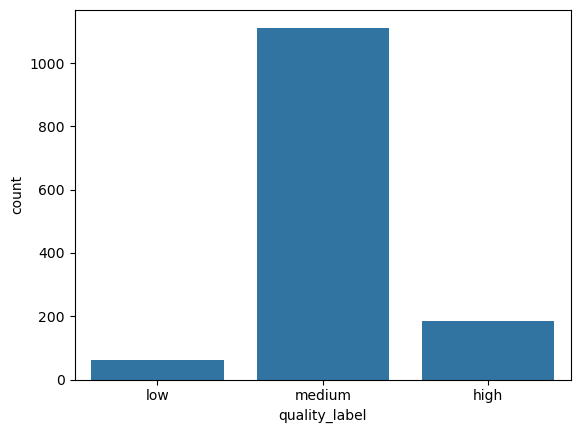

In [ ]:
sns.countplot(x=red_wine_original['quality_label'])
plt.show()

In [ ]:
le = LabelEncoder()
red_wine_original['wine_type'] = le.fit_transform(red_wine_original['wine_type'])
red_wine_original['wine_type'].head()

oe = OrdinalEncoder(categories=[["low", "medium", "high"]], dtype=int) # this is how you can define the label order
red_wine_original['quality_label'] = oe.fit_transform(red_wine_original[['quality_label']])
red_wine_original['quality_label'].head()

0    1
1    1
2    1
3    1
5    1
Name: quality_label, dtype: int32

In [ ]:
from sklearn.model_selection import train_test_split

X = red_wine_original.drop('quality_label', axis = 1) 
y = red_wine_original['quality_label'] 

print("original:", red_wine_original.shape, "\nX:", X.shape, "\ny:", y.shape)

original: (1359, 18) 
X: (1359, 17) 
y: (1359,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=420)
print(X_train, X_test)

      fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
1447            6.8              0.67         0.00             1.9      0.080   
550             6.8              0.51         0.01             2.1      0.074   
889            10.7              0.90         0.34             6.6      0.112   
1010            8.9              0.28         0.45             1.7      0.067   
404             7.7              0.69         0.05             2.7      0.075   
...             ...               ...          ...             ...        ...   
937            12.0              0.63         0.50             1.4      0.071   
664            12.1              0.40         0.52             2.0      0.092   
447             9.3              0.48         0.29             2.1      0.127   
1286            7.1              0.16         0.44             2.5      0.068   
1111            5.4              0.42         0.27             2.0      0.092   

      free_sulfur_dioxide  

In [ ]:
# # Split into training and test sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# # Apply SMOTE to the training data
# smote = SMOTE(k_neighbors = 5, sampling_strategy='auto', random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# # Print before and after class distribution
# print("Original class distribution:", np.bincount(y_train))
# print("Resampled class distribution:", np.bincount(y_train_resampled))

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler(feature_range=(0,1))

# Fit and transform the training data
X_train_scaled4 = scaler.fit_transform(X_train)

# Transform the test data (do NOT fit again)
X_test_scaled4 = scaler.transform(X_test)

### RF, no tuning

In [ ]:
RF_clf = RandomForestClassifier(random_state=42)

RF_clf.fit(X_train_scaled4, y_train)

preds = RF_clf.predict(X_test_scaled4)
preds_tr = RF_clf.predict(X_train_scaled4)

print('Training Accuracy : ', accuracy_score(y_train, preds_tr))
print('Validation Accuracy : ', accuracy_score(y_test, preds))
print()


# Perform 5-fold cross-validation
scores = cross_val_score(model, X_train_scaled4, y_train, cv=5, scoring='accuracy')
print(f'Mean CV Accuracy: {scores.mean()}')
print(f"Cohen Kappa Score: {cohen_kappa_score(y_test, preds)}")

Training Accuracy :  1.0
Validation Accuracy :  0.8294117647058824

Mean CV Accuracy: 0.8400656814449918
Cohen Kappa Score: 0.3302995313455138


In [ ]:
print("Confusion matrix:")
print(confusion_matrix(y_test, preds))

from sklearn.metrics import classification_report
print(classification_report(y_test, preds, target_names=["low","medium","high"]))

Confusion matrix:
[[  0  17   1]
 [  0 263  11]
 [  0  29  19]]
              precision    recall  f1-score   support

         low       0.00      0.00      0.00        18
      medium       0.85      0.96      0.90       274
        high       0.61      0.40      0.48        48

    accuracy                           0.83       340
   macro avg       0.49      0.45      0.46       340
weighted avg       0.77      0.83      0.79       340



d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


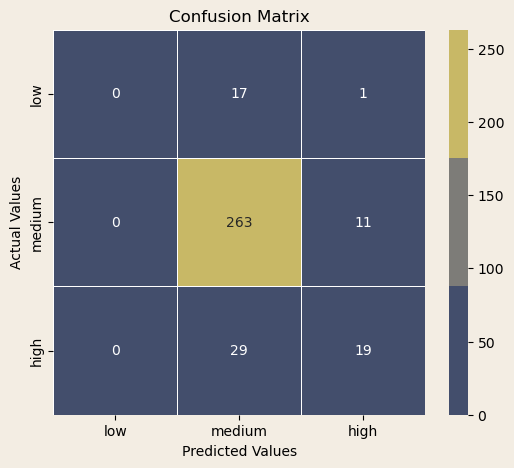

In [ ]:
cm = confusion_matrix(y_test, preds)

# Convert to DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['low', 'medium', 'high'], 
                     columns=['low', 'medium', 'high'])

# Load the cividis colormap from Matplotlib
cividis = plt.get_cmap("cividis")

# Choose specific gradient positions (values from 0 to 1)
colors = [cividis(0.25), cividis(0.5), cividis(0.8)]  # Adjust these values to change the colors

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
# Apply these colors to the heatmap
sns.heatmap(cm_df, annot=True, fmt="d", cmap=sns.color_palette(colors, as_cmap=True), linewidths=0.5, cbar=True)

# Labels and title
plt.title("Confusion Matrix")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.gcf().set_facecolor('#f3ede3')
plt.show()

In [ ]:

# define the tree depths to evaluate
values = [i for i in range(1, 21)]

test_scores =[]
train_scores = []

# evaluate a decision tree for each depth
for i in values:
	# configure the model
	model = RandomForestClassifier(max_depth=i)
	# fit model on the training dataset
	model.fit(X_train, y_train)
	# evaluate on the train dataset
	train_yhat = model.predict(X_train)
	train_acc = accuracy_score(y_train, train_yhat)
	train_scores.append(train_acc)
	# evaluate on the test dataset
	test_yhat = model.predict(X_test)
	test_acc = accuracy_score(y_test, test_yhat)
	test_scores.append(test_acc)
	# summarize progress
	print('>%d, train: %.3f, test: %.3f' % (i, train_acc, test_acc))

>1, train: 0.822, test: 0.806
>2, train: 0.822, test: 0.806
>3, train: 0.852, test: 0.809
>4, train: 0.867, test: 0.800
>5, train: 0.888, test: 0.815
>6, train: 0.906, test: 0.821
>7, train: 0.925, test: 0.818
>8, train: 0.947, test: 0.824
>9, train: 0.959, test: 0.829
>10, train: 0.973, test: 0.824
>11, train: 0.982, test: 0.818
>12, train: 0.984, test: 0.826
>13, train: 0.989, test: 0.826
>14, train: 0.992, test: 0.821
>15, train: 0.997, test: 0.826
>16, train: 1.000, test: 0.818
>17, train: 0.999, test: 0.821
>18, train: 1.000, test: 0.829
>19, train: 1.000, test: 0.818
>20, train: 1.000, test: 0.821


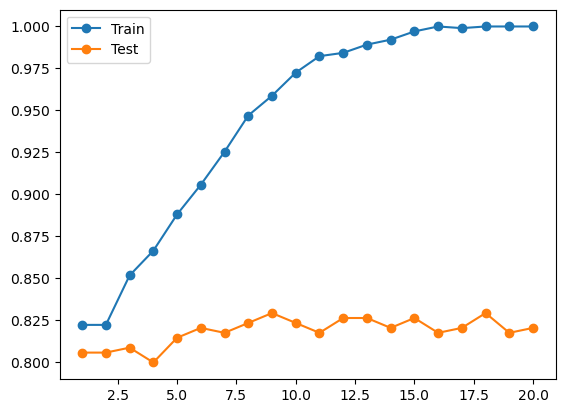

In [ ]:
import matplotlib.pyplot as pyplot

# plot of train and test scores vs tree depth
pyplot.plot(values, train_scores, '-o', label='Train')
pyplot.plot(values, test_scores, '-o', label='Test')
pyplot.legend()
pyplot.show()

In [ ]:
print("Confusion matrix:")
print(confusion_matrix(y_test, preds))

from sklearn.metrics import classification_report
print(classification_report(y_test, preds, target_names=["low","medium","high"]))

Confusion matrix:
[[  0  17   1]
 [  0 263  11]
 [  0  29  19]]
              precision    recall  f1-score   support

         low       0.00      0.00      0.00        18
      medium       0.85      0.96      0.90       274
        high       0.61      0.40      0.48        48

    accuracy                           0.83       340
   macro avg       0.49      0.45      0.46       340
weighted avg       0.77      0.83      0.79       340



d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Define k-fold cross-validation
k = 5  # You can change this (e.g., 10 for more stability)
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Initialize the model
rf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)

# Perform cross-validation
scores = cross_val_score(rf, X_train, y_train, cv=kf, scoring='accuracy')

# Print results
print(f'Cross-Validation Scores: {scores}')
print(f'Mean Accuracy: {np.mean(scores):.3f}')
print(f'Standard Deviation: {np.std(scores):.3f}')


Cross-Validation Scores: [0.82843137 0.84313725 0.83823529 0.80882353 0.8817734 ]
Mean Accuracy: 0.840
Standard Deviation: 0.024


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [8, 9, 10, 11, 12],
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled4, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)
# Best Parameters: {'max_depth': 9, 'max_features': 'sqrt', 'n_estimators': 300}
# Best Accuracy: 0.8459432048681542

Best Parameters: {'max_depth': 11, 'max_features': 'sqrt', 'n_estimators': 300}
Best Accuracy: 0.8469187675070028


>Depth 1, Mean Test Accuracy: 0.700 ± 0.042
>Depth 2, Mean Test Accuracy: 0.708 ± 0.041
>Depth 3, Mean Test Accuracy: 0.727 ± 0.035
>Depth 4, Mean Test Accuracy: 0.726 ± 0.031
>Depth 5, Mean Test Accuracy: 0.733 ± 0.026
>Depth 6, Mean Test Accuracy: 0.728 ± 0.022
>Depth 7, Mean Test Accuracy: 0.736 ± 0.021
>Depth 8, Mean Test Accuracy: 0.735 ± 0.025
>Depth 9, Mean Test Accuracy: 0.733 ± 0.023
>Depth 10, Mean Test Accuracy: 0.729 ± 0.020
>Depth 11, Mean Test Accuracy: 0.732 ± 0.020
>Depth 12, Mean Test Accuracy: 0.741 ± 0.016
>Depth 13, Mean Test Accuracy: 0.728 ± 0.018
>Depth 14, Mean Test Accuracy: 0.726 ± 0.018
>Depth 15, Mean Test Accuracy: 0.729 ± 0.018
>Depth 16, Mean Test Accuracy: 0.725 ± 0.015
>Depth 17, Mean Test Accuracy: 0.720 ± 0.016
>Depth 18, Mean Test Accuracy: 0.720 ± 0.012
>Depth 19, Mean Test Accuracy: 0.713 ± 0.019
>Depth 20, Mean Test Accuracy: 0.715 ± 0.018


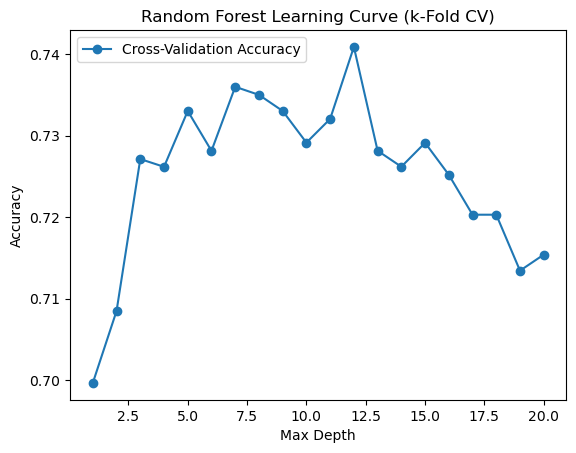

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Define max depth values to test
values = range(1, 21)

# Define k-fold cross-validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Lists to store mean accuracy scores
train_scores = []
test_scores = []

# Loop through different max_depth values
for i in values:
    # Configure the model
    model = RandomForestClassifier(n_estimators=100, max_depth=i, random_state=42)

    # Perform k-fold cross-validation
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')

    # Store mean accuracy score
    mean_acc = np.mean(scores)
    std_acc = np.std(scores)

    test_scores.append(mean_acc)

    # Print progress
    print(f'>Depth {i}, Mean Test Accuracy: {mean_acc:.3f} ± {std_acc:.3f}')

# Plot the learning curve
plt.plot(values, test_scores, marker='o', label='Cross-Validation Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Random Forest Learning Curve (k-Fold CV)')
plt.legend()
plt.show()


### XGB, no tuning

In [ ]:
# Initialize the model
model = XGBClassifier()


model.fit(X_train_scaled4, y_train)
train_preds = model.predict(X_train_scaled4)
test_preds = model.predict(X_test_scaled4)

print('Training Accuracy : ', accuracy_score(y_train, train_preds))
print('Validation Accuracy : ', accuracy_score(y_test, test_preds))
print()

# Perform 5-fold cross-validation
scores = cross_val_score(model, X_train_scaled4, y_train, cv=5, scoring='accuracy')
print(f'Mean CV Accuracy: {scores.mean()}')


Training Accuracy :  1.0
Validation Accuracy :  0.7529411764705882

Mean CV Accuracy: 0.6996667632570268


### Random Forest with HP Tuning

In [ ]:
import numpy as np

n_estimators = np.arange(10,201,10)
max_depth = np.arange(8,14,1)
min_samples_split = np.arange(2, 15, 2)
max_features = ["sqrt", "log2", None]

param_grid = {
  'n_estimators': n_estimators,
  'max_depth': max_depth,
  'min_samples_split': min_samples_split,
  'max_features': max_features,
}

param_grid

from sklearn.model_selection import RandomizedSearchCV

# redefine model
RF_clf = RandomForestClassifier(random_state=42)

RS_grid = RandomizedSearchCV(estimator=RF_clf, param_distributions=param_grid, n_iter=10)
RS_grid

RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                   param_distributions={'max_depth': array([ 8,  9, 10, 11, 12, 13]),
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14]),
                                        'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200])})

In [ ]:
RS_grid.fit(X_train_scaled4, y_train)

RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                   param_distributions={'max_depth': array([ 8,  9, 10, 11, 12, 13]),
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14]),
                                        'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200])})

In [ ]:
print(
  'best score: ', RS_grid.best_score_,
  '\nparams: ', RS_grid.best_params_
)

best score:  0.846928426543031 
params:  {'n_estimators': 140, 'min_samples_split': 8, 'max_features': 'log2', 'max_depth': 8}


In [ ]:
class_weights = {0: 1, 1: 1, 2: 5}

model = RandomForestClassifier(
    n_estimators= 300,
    # min_samples_split = 10,
    max_features= 'sqrt',
    max_depth = 11,
    # class_weight = class_weights
)

model.fit(X_train_scaled4,y_train)
train_preds = model.predict(X_train_scaled4)
test_preds = model.predict(X_test_scaled4)

print('Training Accuracy : ', accuracy_score(y_train, train_preds))
print('Validation Accuracy : ', accuracy_score(y_test, test_preds))
print()

# Perform 5-fold cross-validation
scores = cross_val_score(model, X_train_scaled4, y_train, cv=5, scoring='accuracy')
print(f'Mean CV Accuracy: {scores.mean()}')
print(f"Cohen Kappa Score: {cohen_kappa_score(y_test, test_preds)}")




Training Accuracy :  0.9793915603532876
Validation Accuracy :  0.8264705882352941

Mean CV Accuracy: 0.8459432048681542
Cohen Kappa Score: 0.31348391512662555


In [ ]:
print("Confusion matrix:")
print(confusion_matrix(y_test, test_preds))

from sklearn.metrics import classification_report
print(classification_report(y_test, test_preds, target_names=["low","medium","high"]))

Confusion matrix:
[[125  39   0]
 [ 37 134   1]
 [  0   4   0]]
              precision    recall  f1-score   support

         low       0.77      0.76      0.77       164
      medium       0.76      0.78      0.77       172
        high       0.00      0.00      0.00         4

    accuracy                           0.76       340
   macro avg       0.51      0.51      0.51       340
weighted avg       0.76      0.76      0.76       340



In [ ]:
class_weights = {0: 1, 1: 1, 2: 5}

model = RandomForestClassifier(
    n_estimators= 120,
    min_samples_split = 8,
    max_features= 'sqrt',
    max_depth = 9,
    class_weight = class_weights
)

model.fit(X_train_scaled4,y_train)
train_preds = model.predict(X_train_scaled4)
test_preds = model.predict(X_test_scaled4)

print('Training Accuracy : ', accuracy_score(y_train, train_preds))
print('Validation Accuracy : ', accuracy_score(y_test, test_preds))
print()

# Perform 5-fold cross-validation
scores = cross_val_score(model, X_train_scaled4, y_train, cv=5, scoring='accuracy')
print(f'Mean CV Accuracy: {scores.mean()}')
print(f"Cohen Kappa Score: {cohen_kappa_score(y_test, test_preds)}")

Training Accuracy :  0.9421000981354269
Validation Accuracy :  0.8029411764705883

Mean CV Accuracy: 0.8263112141408288
Cohen Kappa Score: 0.2763659466327828


In [ ]:
print("Confusion matrix:")
print(confusion_matrix(y_test, test_preds))

from sklearn.metrics import classification_report
print(classification_report(y_test, test_preds, target_names=["low","medium","high"]))

Confusion matrix:
[[  0  17   1]
 [  0 254  20]
 [  0  29  19]]
              precision    recall  f1-score   support

         low       0.00      0.00      0.00        18
      medium       0.85      0.93      0.89       274
        high       0.47      0.40      0.43        48

    accuracy                           0.80       340
   macro avg       0.44      0.44      0.44       340
weighted avg       0.75      0.80      0.77       340



d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


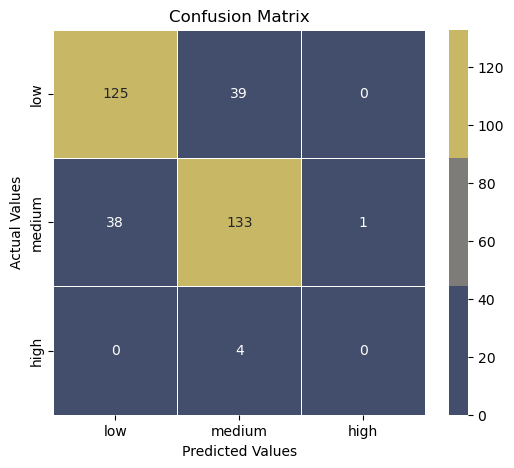

In [ ]:
# Compute confusion matrix

cm = confusion_matrix(y_test, test_preds)

# Convert to DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['low', 'medium', 'high'], 
                     columns=['low', 'medium', 'high'])

# Load the cividis colormap from Matplotlib
cividis = plt.get_cmap("cividis")

# Choose specific gradient positions (values from 0 to 1)
colors = [cividis(0.25), cividis(0.5), cividis(0.8)]  # Adjust these values to change the colors

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
# Apply these colors to the heatmap
sns.heatmap(cm_df, annot=True, fmt="d", cmap=sns.color_palette(colors, as_cmap=True), linewidths=0.5, cbar=True)

# Labels and title
plt.title("Confusion Matrix")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.show()

### XGB with HP tuning

In [ ]:
xgb_model = XGBClassifier(objective='multi:softmax', num_class=len(set(y_train)))

# Define the hyperparameter grid
param_dist = {
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 200, 500],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0.1, 0.3, 0.5],
    'reg_lambda': [0.1, 0.3, 0.5]
}
    

# Perform randomized search with cross-validation
RS_grid = RandomizedSearchCV(xgb_model, param_distributions=param_dist, n_iter=50, cv=5, verbose=1, n_jobs=-1)

# Fit the model
RS_grid.fit(X_train_scaled4, y_train)

# Print the best score and parameters
print('Best score: ', RS_grid.best_score_)
print('Best parameters: ', RS_grid.best_params_)

# best scores:     
# 77,6%, AUC- 70,5%  - subsample = 0.8,reg_lambda=0.5,reg_alpha=0.3,n_estimators=200,max_depth=5,learning_rate=0.2,colsample_bytree = 0.8 
# 75,58%, AUC - 72,12% max_depth=3, learning_rate=0.05, n_estimators=200, reg_alpha=0.1, reg_lambda=3, objective='multi:softmax', num_class=len(set(y_train)), random_state = 11
# Best score:  0.849855114459577
# Best parameters:  {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 0.3, 'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best score:  0.7300734086738144
Best parameters:  {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 0.3, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [ ]:
# Initialize the model
model = XGBClassifier(
    max_depth=3,
    learning_rate=0.05,
    n_estimators=200,
    reg_alpha=0.1,
    reg_lambda=3,
    objective='multi:softmax',
    num_class=len(set(y_train)),
    random_state = 11
)

model.fit(X_train_scaled4, y_train)
train_preds = model.predict(X_train_scaled4)
test_preds = model.predict(X_test_scaled4)

print('Training Accuracy : ', accuracy_score(y_train, train_preds))
print('Validation Accuracy : ', accuracy_score(y_test, test_preds))
print()

# Perform 5-fold cross-validation
scores = cross_val_score(model, X_train_scaled4, y_train, cv=5, scoring='accuracy')
print(f'Mean CV Accuracy Score: {scores.mean()}')

Training Accuracy :  0.8626104023552502
Validation Accuracy :  0.7558823529411764

Mean CV Accuracy Score: 0.7212595382980778


In [ ]:
print("Confusion matrix:")
print(confusion_matrix(y_test, test_preds))

from sklearn.metrics import classification_report
print(classification_report(y_test, test_preds, target_names=["low","medium","high"]))

Confusion matrix:
[[126  38   0]
 [ 41 131   0]
 [  1   3   0]]
              precision    recall  f1-score   support

         low       0.75      0.77      0.76       164
      medium       0.76      0.76      0.76       172
        high       0.00      0.00      0.00         4

    accuracy                           0.76       340
   macro avg       0.50      0.51      0.51       340
weighted avg       0.75      0.76      0.75       340



d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
model = XGBClassifier(
    subsample = 0.8,
    reg_lambda = 0.1, 
    reg_alpha = 0.3,
    n_estimators = 50, 
    max_depth =  3, 
    learning_rate = 0.1,
    colsample_bytree =1.0)

model.fit(X_train_scaled4, y_train)
train_preds = model.predict(X_train_scaled4)
test_preds = model.predict(X_test_scaled4)

print('Training Accuracy : ', accuracy_score(y_train, train_preds))
print('Validation Accuracy : ', accuracy_score(y_test, test_preds))
print()

# Perform 5-fold cross-validation
scores = cross_val_score(model, X_train_scaled4, y_train, cv=5, scoring='accuracy')
print(f'Mean CV Accuracy Score: {scores.mean()}')

Training Accuracy :  0.8223748773307163
Validation Accuracy :  0.7647058823529411

Mean CV Accuracy Score: 0.7281222833961171


In [ ]:
print("Confusion matrix:")
print(confusion_matrix(y_test, test_preds))

from sklearn.metrics import classification_report
print(classification_report(y_test, test_preds, target_names=["low","medium","high"]))

Confusion matrix:
[[126  38   0]
 [ 38 134   0]
 [  0   4   0]]
              precision    recall  f1-score   support

         low       0.77      0.77      0.77       164
      medium       0.76      0.78      0.77       172
        high       0.00      0.00      0.00         4

    accuracy                           0.76       340
   macro avg       0.51      0.52      0.51       340
weighted avg       0.76      0.76      0.76       340



d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


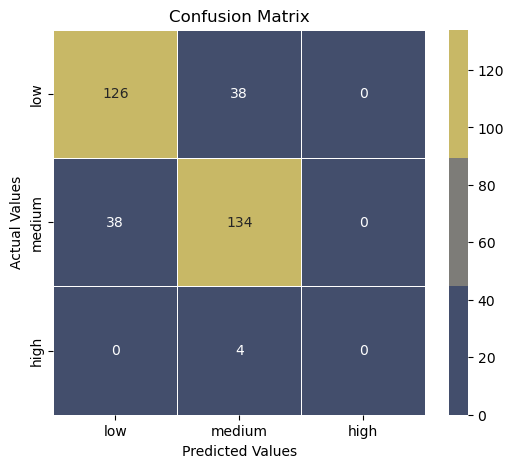

In [ ]:
# Compute confusion matrix

cm = confusion_matrix(y_test, test_preds)

# Convert to DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['low', 'medium', 'high'], 
                     columns=['low', 'medium', 'high'])

# Load the cividis colormap from Matplotlib
cividis = plt.get_cmap("cividis")

# Choose specific gradient positions (values from 0 to 1)
colors = [cividis(0.25), cividis(0.5), cividis(0.8)]  # Adjust these values to change the colors

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
# Apply these colors to the heatmap
sns.heatmap(cm_df, annot=True, fmt="d", cmap=sns.color_palette(colors, as_cmap=True), linewidths=0.5, cbar=True)

# Labels and title
plt.title("Confusion Matrix")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.show()

### Dropping columns

In [ ]:
red_wine_dropped_columns = red_wine_original.drop(['residual_sugar','fixed_acidity','pH','free_sulfur_dioxide','acidity_to_alcohol_ratio'], axis = 1)

In [ ]:
red_wine_dropped_columns

,volatile_acidity,citric_acid,chlorides,total_sulfur_dioxide,density,sulphates,alcohol,quality_label,wine_type,alcohol_g_per_L,SO2_ratio,alc_acid_ratio,density_to_sugar_ratio
0,0.700,0.00,0.076,34.0,0.99780,0.56,9.4,1,0,74.166,32.352941,127.027027,0.525158
1,0.880,0.00,0.098,67.0,0.99680,0.68,9.8,1,0,77.322,37.313433,125.641026,0.383385
2,0.760,0.04,0.092,54.0,0.99700,0.65,9.8,1,0,77.322,27.777778,125.641026,0.433478
3,0.280,0.56,0.075,60.0,0.99800,0.58,9.8,1,0,77.322,28.333333,87.500000,0.525263
5,0.660,0.00,0.075,40.0,0.99780,0.56,9.4,1,0,74.166,32.500000,127.027027,0.554333
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1593,0.620,0.08,0.068,38.0,0.99651,0.82,9.5,1,0,74.955,73.684211,139.705882,0.524479
1594,0.600,0.08,0.090,44.0,0.99490,0.58,10.5,1,0,82.845,72.727273,169.354839,0.497450
1595,0.550,0.10,0.062,51.0,0.99512,0.76,11.2,1,0,88.368,76.470588,189.830508,0.452327
1597,0.645,0.12,0.075,44.0,0.99547,0.71,10.2,1,0,80.478,72.727273,172.881356,0.497735


In [ ]:
from sklearn.model_selection import train_test_split

X = red_wine_dropped_columns.drop('quality_label', axis = 1) 
y = red_wine_dropped_columns['quality_label'] 

print("original:", red_wine_dropped_columns.shape, "\nX:", X.shape, "\ny:", y.shape)

original: (1359, 13) 
X: (1359, 12) 
y: (1359,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=420)
print(X_train, X_test)

      volatile_acidity  citric_acid  chlorides  total_sulfur_dioxide  density  \
1447              0.67         0.00      0.080                  39.0  0.99701   
550               0.51         0.01      0.074                  25.0  0.99580   
889               0.90         0.34      0.112                  99.0  1.00289   
1010              0.28         0.45      0.067                  12.0  0.99354   
404               0.69         0.05      0.075                  27.0  0.99740   
...                ...          ...        ...                   ...      ...   
937               0.63         0.50      0.071                  26.0  0.99791   
664               0.40         0.52      0.092                  54.0  1.00000   
447               0.48         0.29      0.127                  16.0  0.99680   
1286              0.16         0.44      0.068                  31.0  0.99328   
1111              0.42         0.27      0.092                  55.0  0.99471   

      sulphates  alcohol  w

In [ ]:
# # Apply SMOTE to the training data
# smote = SMOTE(sampling_strategy='auto', random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# # Print before and after class distribution
# print("Original class distribution:", np.bincount(y_train))
# print("Resampled class distribution:", np.bincount(y_train_resampled))


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler(feature_range=(0,1))

# Fit and transform the training data
X_train_scaled5 = scaler.fit_transform(X_train)

# Transform the test data (do NOT fit again)
X_test_scaled5 = scaler.transform(X_test)

In [ ]:
RF_clf = RandomForestClassifier(random_state=42)

class_weights = {0: 1, 1: 1, 2: 5}

RF_clf.fit(X_train_scaled5,y_train)
train_preds = RF_clf.predict(X_train_scaled5)
test_preds = RF_clf.predict(X_test_scaled5)

print('Training Accuracy : ', accuracy_score(y_train, train_preds))
print('Validation Accuracy : ', accuracy_score(y_test, test_preds))
print()

# Perform 5-fold cross-validation
scores = cross_val_score(model, X_train_scaled5, y_train, cv=5, scoring='accuracy')
print(f'Mean CV Accuracy: {scores.mean()}')

Training Accuracy :  1.0
Validation Accuracy :  0.8235294117647058

Mean CV Accuracy: 0.8312228339611707


In [ ]:
print("Confusion matrix:")
print(confusion_matrix(y_test, test_preds))

from sklearn.metrics import classification_report
print(classification_report(y_test, test_preds, target_names=["low","medium","high"]))

Confusion matrix:
[[  1  16   1]
 [  0 263  11]
 [  0  32  16]]
              precision    recall  f1-score   support

         low       1.00      0.06      0.11        18
      medium       0.85      0.96      0.90       274
        high       0.57      0.33      0.42        48

    accuracy                           0.82       340
   macro avg       0.81      0.45      0.48       340
weighted avg       0.82      0.82      0.79       340



In [ ]:
print(f"Cohen Kappa Score: {cohen_kappa_score(y_test, preds)}")

Cohen Kappa Score: 0.3302995313455138


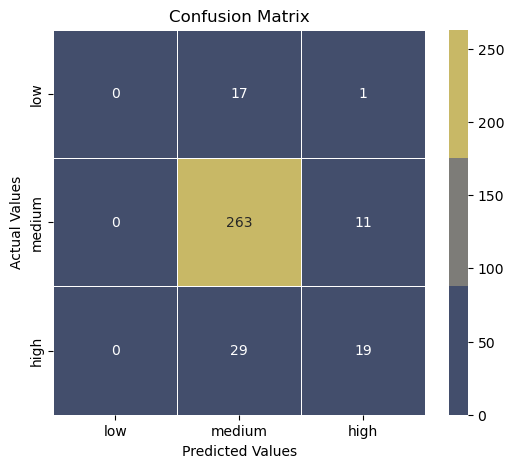

In [ ]:
# Compute confusion matrix

cm = confusion_matrix(y_test, preds)

# Convert to DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['low', 'medium', 'high'], 
                     columns=['low', 'medium', 'high'])

# Load the cividis colormap from Matplotlib
cividis = plt.get_cmap("cividis")

# Choose specific gradient positions (values from 0 to 1)
colors = [cividis(0.25), cividis(0.5), cividis(0.8)]  # Adjust these values to change the colors

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
# Apply these colors to the heatmap
sns.heatmap(cm_df, annot=True, fmt="d", cmap=sns.color_palette(colors, as_cmap=True), linewidths=0.5, cbar=True)

# Labels and title
plt.title("Confusion Matrix")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.show()


### RF with Tuninig

In [ ]:
import numpy as np

n_estimators = np.arange(10,201,10)
max_depth = np.arange(5, 55, 5)
min_samples_split = np.arange(2, 15, 2)
max_features = ["sqrt", "log2", None]

param_grid = {
  'n_estimators': n_estimators,
  'max_depth': max_depth,
  'min_samples_split': min_samples_split,
  'max_features': max_features,
}

param_grid

{'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
        140, 150, 160, 170, 180, 190, 200]),
 'max_depth': array([ 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]),
 'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14]),
 'max_features': ['sqrt', 'log2', None]}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# redefine model
RF_clf = RandomForestClassifier(random_state=420)

RS_grid = RandomizedSearchCV(estimator=RF_clf, param_distributions=param_grid, n_iter=10)
RS_grid

RandomizedSearchCV(estimator=RandomForestClassifier(random_state=420),
                   param_distributions={'max_depth': array([ 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]),
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14]),
                                        'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200])})

In [ ]:
RS_grid.fit(X_train_scaled5, y_train)
print(
  'best score: ', RS_grid.best_score_,
  '\nparams: ', RS_grid.best_params_
)

best score:  0.8439824205544287 
params:  {'n_estimators': 200, 'min_samples_split': 6, 'max_features': 'log2', 'max_depth': 25}


In [ ]:
model = RandomForestClassifier(
    n_estimators= 100,
    max_depth = 10,
    max_features= "log2",
    min_samples_split = 5
)

model.fit(X_train_scaled5,y_train)
train_preds = model.predict(X_train_scaled5)
test_preds = model.predict(X_test_scaled5)

print('Training Accuracy : ', accuracy_score(y_train, train_preds))
print('Validation Accuracy : ', accuracy_score(y_test, test_preds))
print()

# Perform 5-fold cross-validation
scores = cross_val_score(model, X_train_scaled5, y_train, cv=5, scoring='accuracy')
print(f'Mean CV Accuracy: {scores.mean()}')



Training Accuracy :  0.9489695780176644
Validation Accuracy :  0.8323529411764706

Mean CV Accuracy: 0.8429971988795518


In [ ]:
print(f"Cohen Kappa Score: {cohen_kappa_score(y_test, test_preds)}")

Cohen Kappa Score: 0.32703659976387256


In [ ]:
print("Confusion matrix:")
print(confusion_matrix(y_test, test_preds))

from sklearn.metrics import classification_report
print(classification_report(y_test, test_preds, target_names=["low","medium","high"]))

Confusion matrix:
[[  0  17   1]
 [  1 265   8]
 [  0  30  18]]
              precision    recall  f1-score   support

         low       0.00      0.00      0.00        18
      medium       0.85      0.97      0.90       274
        high       0.67      0.38      0.48        48

    accuracy                           0.83       340
   macro avg       0.51      0.45      0.46       340
weighted avg       0.78      0.83      0.80       340



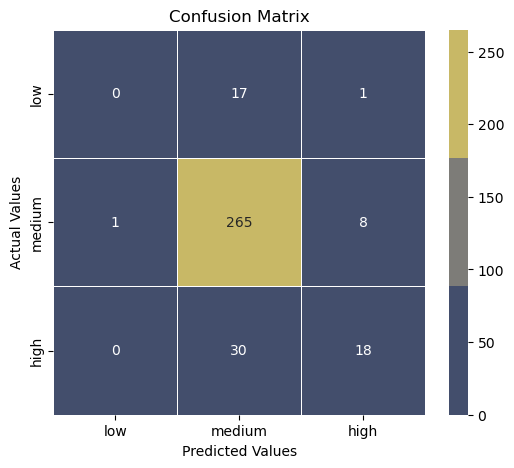

In [ ]:
# Compute confusion matrix

cm = confusion_matrix(y_test, test_preds)

# Convert to DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['low', 'medium', 'high'], 
                     columns=['low', 'medium', 'high'])

# Load the cividis colormap from Matplotlib
cividis = plt.get_cmap("cividis")

# Choose specific gradient positions (values from 0 to 1)
colors = [cividis(0.25), cividis(0.5), cividis(0.8)]  # Adjust these values to change the colors

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
# Apply these colors to the heatmap
sns.heatmap(cm_df, annot=True, fmt="d", cmap=sns.color_palette(colors, as_cmap=True), linewidths=0.5, cbar=True)

# Labels and title
plt.title("Confusion Matrix")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.show()
